# 08 · Del resultado a una recomendación defendible

**Integra RA1–RA3, todos los CE.** Entrega formativa: notebook, memo de una página, tablero y exposición de cinco minutos. Una sesión más trabajo autónomo.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 60–90 min orientativos.

**Objetivo:** Defender una recomendación con efecto, incertidumbre y costo.

**Preparación:** Resultados reproducibles de los módulos 01–07.

**Ejemplo de referencia:** ComercioSur: unir comparación de campañas, costo por minuto y supuestos económicos.

**Práctica:** Redactar un memo y defenderlo frente a un escenario que invierte la decisión.

**Criterio de logro:** Entregar memo, cálculo, gráfico y defensa con población, sensibilidad y siguiente evidencia.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-comunicacion)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'02_Estadistica_Business_Analytics/reproducibilidad'))
from eba_recursos import *
df=pedidos()
plt.rcParams.update({'figure.figsize':(7,3.4),'axes.spines.top':False,'axes.spines.right':False})


<a id="pregunta"></a>
## Caso integrador y plan previo

ComercioSur dispone de A, B y C; desea reducir al menos 3 minutos sin deteriorar resolución. Antes del cálculo: definir tiempo como resultado principal, contrastes B−A/C−A, α familiar=.05, costo B=.5 y C=1 UM/pedido, minuto=.2 UM. Estas cifras son supuestos, no costos observados. No inferioridad en resolución exige margen y tamaño apropiados: no basta un p>.05.

In [2]:
display(df.groupby('campana').agg(n=('id','size'),tiempo=('tiempo_min','mean'),resueltos=('resuelto','sum')));print('Verificar unidad, asignación aleatoria, independencia y exclusiones antes de inferir.')

,n,tiempo,resueltos
campana,,,
A,209,40.131196,142
B,209,36.062919,160
C,182,32.028571,151


Verificar unidad, asignación aleatoria, independencia y exclusiones antes de inferir.


<a id="evidencia"></a>
## Comparaciones primarias con ajuste

A diferencia del laboratorio exploratorio de tres pares, aquí se fijan solo B−A y C−A; Holm se aplica a esta familia de dos contrastes. Los IC siguen siendo individuales. Observe el intervalo del beneficio para no decidir por el estimador puntual solamente.

In [3]:
a=df[df.campana.eq('A')].tiempo_min;tabla=pd.DataFrame([{'campana':g,**welch(df[df.campana.eq(g)].tiempo_min,a)} for g in ['B','C']]);tabla['p_Holm']=holm(tabla.p);tabla['costo']=tabla.campana.map({'B':.5,'C':1.});tabla['beneficio_UM']=-tabla.diferencia*.2-tabla.costo;tabla['beneficio_li']=-tabla.ls*.2-tabla.costo;tabla['beneficio_ls']=-tabla.li*.2-tabla.costo;display(tabla)

,campana,diferencia,t,gl,p,li,ls,p_Holm,costo,beneficio_UM,beneficio_li,beneficio_ls
0,B,-4.068278,-5.940487,415.418546,6.014918e-09,-5.414460,-2.722096,6.014918e-09,0.5,0.313656,0.044419,0.582892
1,C,-8.102625,-11.162512,372.101899,3.765548e-25,-9.529963,-6.675287,7.531095e-25,1.0,0.620525,0.335057,0.905993


<a id="comunicar"></a>
## Una figura, un mensaje y un límite

Comunicar primero cuánto cambia el tiempo, después incertidumbre y efecto práctico. Título preciso: comparación simulada; no afirmar universalidad. Actividad: redacte sin la palabra significativo, conserve n y unidades, indique qué evidencia adicional necesita sobre resolución.

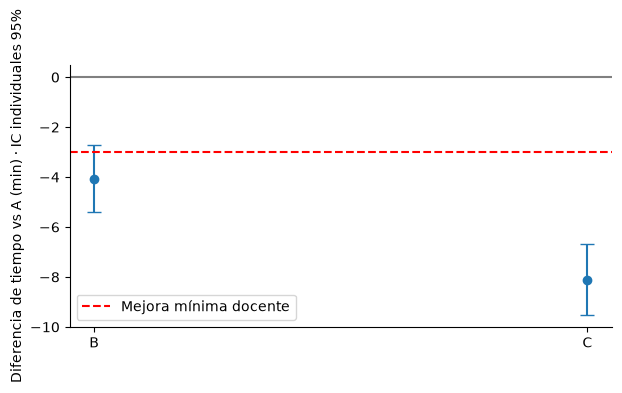

,campana,beneficio_UM,beneficio_li,beneficio_ls
0,B,0.313656,0.044419,0.582892
1,C,0.620525,0.335057,0.905993


In [4]:
plt.errorbar(tabla.campana,tabla.diferencia,yerr=[tabla.diferencia-tabla.li,tabla.ls-tabla.diferencia],fmt='o',capsize=5);plt.axhline(0,color='gray');plt.axhline(-3,color='red',linestyle='--',label='Mejora mínima docente');plt.ylabel('Diferencia de tiempo vs A (min) · IC individuales 95%');plt.legend();plt.show();display(tabla[['campana','beneficio_UM','beneficio_li','beneficio_ls']])

<a id="sensibilidad"></a>
## Incertidumbre económica y estadística

Mover precio del minuto cambia el beneficio, no el efecto estadístico. Los IC transformados consideran costos fijos; no incluyen incertidumbre económica. Añada sensibilidad a escala del proceso y costo de implementación antes de recomendar despliegue.

In [5]:
@widgets.interact(valor=widgets.FloatSlider(value=.2,min=.05,max=.5,step=.05))
def sensibilidad(valor):
    s=tabla[['campana','costo']].copy();s['beneficio']=-tabla.diferencia*valor-tabla.costo;s['li']=-tabla.ls*valor-tabla.costo;s['ls']=-tabla.li*valor-tabla.costo;display(s)

interactive(children=(FloatSlider(value=0.2, description='valor', max=0.5, min=0.05, step=0.05), Output()), _d…

<a id="rubrica"></a>
## Rúbrica y solución orientadora

Autoevaluación 0–3 por dimensión: 0 ausente, 1 presenta con errores, 2 correcto sin conectar con decisión, 3 correcto y justificado con límites. Dimensiones: pregunta/diseño, método/supuestos, ejecución/reproducción, interpretación/incertidumbre, visualización/herramientas y comunicación/acción. La decisión orientadora es evaluar piloto condicionado a beneficio, resolución y representatividad; no hay aprobación comercial automática por p.

In [6]:
display(pd.DataFrame({'dimension':['Pregunta y diseño','Método y supuestos','Ejecución reproducible','Interpretación e incertidumbre','Visualización y herramientas','Comunicación y acción'],'evidencia':['Estimando, población y asignación','Contraste y familia predefinidos','Ejecutar todo y verificar agregados','Efecto, IC, costo y límites','Python y Excel conciliados','Memo, condición de piloto y seguimiento'],'maximo':[3]*6}));print('Máximo 18 puntos formativos. No es una escala de notas institucional.')

,dimension,evidencia,maximo
0,Pregunta y diseño,"Estimando, población y asignación",3
1,Método y supuestos,Contraste y familia predefinidos,3
2,Ejecución reproducible,Ejecutar todo y verificar agregados,3
3,Interpretación e incertidumbre,"Efecto, IC, costo y límites",3
4,Visualización y herramientas,Python y Excel conciliados,3
5,Comunicación y acción,"Memo, condición de piloto y seguimiento",3


Máximo 18 puntos formativos. No es una escala de notas institucional.


## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [7]:
auto_08=pregunta('¿p>.05 en resolución demuestra que una campaña no la deteriora?','Sí, demuestra igualdad','No, no rechazo no prueba equivalencia ni no inferioridad','Defina un margen defendible y un diseño con precisión suficiente para evaluar no inferioridad.')
display(auto_08)